In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re
from tqdm import tqdm

%load_ext autoreload
%autoreload 2

from utils import load_excel_sheets, process_benchmark_stats, aggregate_stats, global_model_list

In [2]:
dfs = load_excel_sheets('../data/PB2/P1','data/PB1/P1.2')

print("\nLoaded dataframe keys:", list(dfs.keys()))

 Loaded: ChatGPT-5.1_t.xlsx Sheets:[3/3]
 Loaded: Gemini 2.5_t.xlsx Sheets:[3/3]
 Loaded: Gemini 3.0_t.xlsx Sheets:[3/3]
 Loaded: DeepSeek-V3.2_t.xlsx Sheets:[3/3]

Loaded dataframe keys: ['P1_ChatGPT-5.1_CM', 'P1_ChatGPT-5.1_EM', 'P1_ChatGPT-5.1_QM', 'P1_Gemini 2.5_CM', 'P1_Gemini 2.5_EM', 'P1_Gemini 2.5_QM', 'P1_Gemini 3.0_CM', 'P1_Gemini 3.0_EM', 'P1_Gemini 3.0_QM', 'P1_DeepSeek-V3.2_CM', 'P1_DeepSeek-V3.2_EM', 'P1_DeepSeek-V3.2_QM']


In [3]:
process_benchmark_stats(dfs)
# Verify the result with the first dataframe
if dfs:
    first_key = list(dfs.keys())[0]
    print(f"\nFirst 5 rows of {first_key}:")
    display(dfs[first_key].head())

Processing DataFrames: 100%|██████████| 12/12 [00:00<00:00, 796.98it/s]


First 5 rows of P1_ChatGPT-5.1_CM:


,Question Number,Available Marks,Solution 1,Solution 2,Solution 3,Dir,Model,Sheet,key,mean solution,std solution,mean percentage mark,std percentage
0,1,6,6,6,6,P1,ChatGPT-5.1,CM,P1_ChatGPT-5.1_CM,6.000000,0.000000,100.000000,0.000000
1,2,9,9,9,9,P1,ChatGPT-5.1,CM,P1_ChatGPT-5.1_CM,9.000000,0.000000,100.000000,0.000000
2,3,13,11,13,13,P1,ChatGPT-5.1,CM,P1_ChatGPT-5.1_CM,12.333333,1.154701,94.871795,8.882312
3,4,10,10,10,10,P1,ChatGPT-5.1,CM,P1_ChatGPT-5.1_CM,10.000000,0.000000,100.000000,0.000000
4,5,7,7,7,7,P1,ChatGPT-5.1,CM,P1_ChatGPT-5.1_CM,7.000000,0.000000,100.000000,0.000000


In [4]:
# Create master df and summary df for plotting
master_df, summary_stats = aggregate_stats(dfs)

display(master_df.head())
display(summary_stats.head())

/Users/jonah/Github - Projects/LLM Project paper/AI-in-Physics-in-Education-j/Plot code/utils.py:128: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_stats = master_df.groupby(['Dir', 'Model', 'Sheet']).agg(


,Question Number,Available Marks,Solution 1,Solution 2,Solution 3,Dir,Model,Sheet,key,mean solution,std solution,mean percentage mark,std percentage
18,1,6,6,6,6,P1,Gemini 2.5,CM,P1_Gemini 2.5_CM,6.000000,0.000000,100.000000,0.000000
19,2,9,9,9,9,P1,Gemini 2.5,CM,P1_Gemini 2.5_CM,9.000000,0.000000,100.000000,0.000000
20,3,13,10,13,11,P1,Gemini 2.5,CM,P1_Gemini 2.5_CM,11.333333,1.527525,87.179487,11.750194
21,4,10,10,10,9,P1,Gemini 2.5,CM,P1_Gemini 2.5_CM,9.666667,0.577350,96.666667,5.773503
22,5,7,7,7,7,P1,Gemini 2.5,CM,P1_Gemini 2.5_CM,7.000000,0.000000,100.000000,0.000000


,Dir,Model,Sheet,Total_Mean%,Total_Std,Total_Std_error%
0,P1,Gemini 2.5,CM,96.226415,5.137812,2.097503
1,P1,Gemini 2.5,EM,94.557823,5.723985,2.336807
2,P1,Gemini 2.5,QM,100.000000,0.000000,0.000000
3,P1,ChatGPT-5.1,CM,98.742138,2.093581,0.854701
4,P1,ChatGPT-5.1,EM,97.959184,3.291752,1.343852


,Dir,Model,Sheet,Total_Mean%,Total_Std,Total_Std_error%
0,P1,Gemini 2.5,CM,96.226415,5.137812,2.097503
3,P1,ChatGPT-5.1,CM,98.742138,2.093581,0.854701
6,P1,Gemini 3.0,CM,99.371069,2.268046,0.925926
9,P1,DeepSeek-V3.2,CM,100.000000,0.000000,0.000000


Dirs: ['P1']
Sheets: ['CM' 'EM' 'QM']


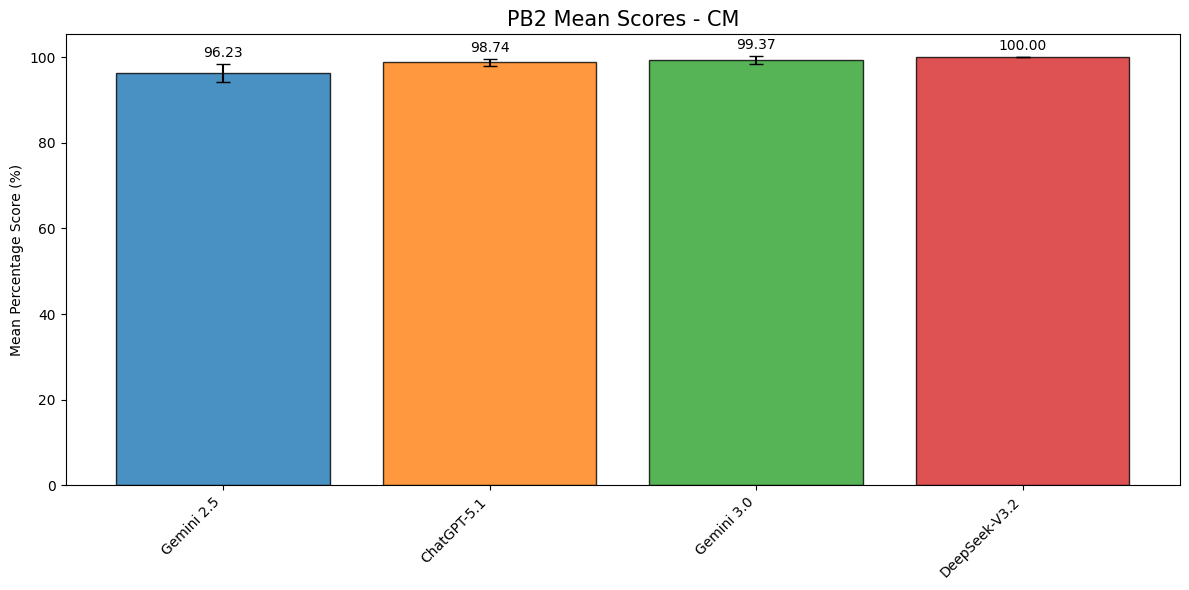

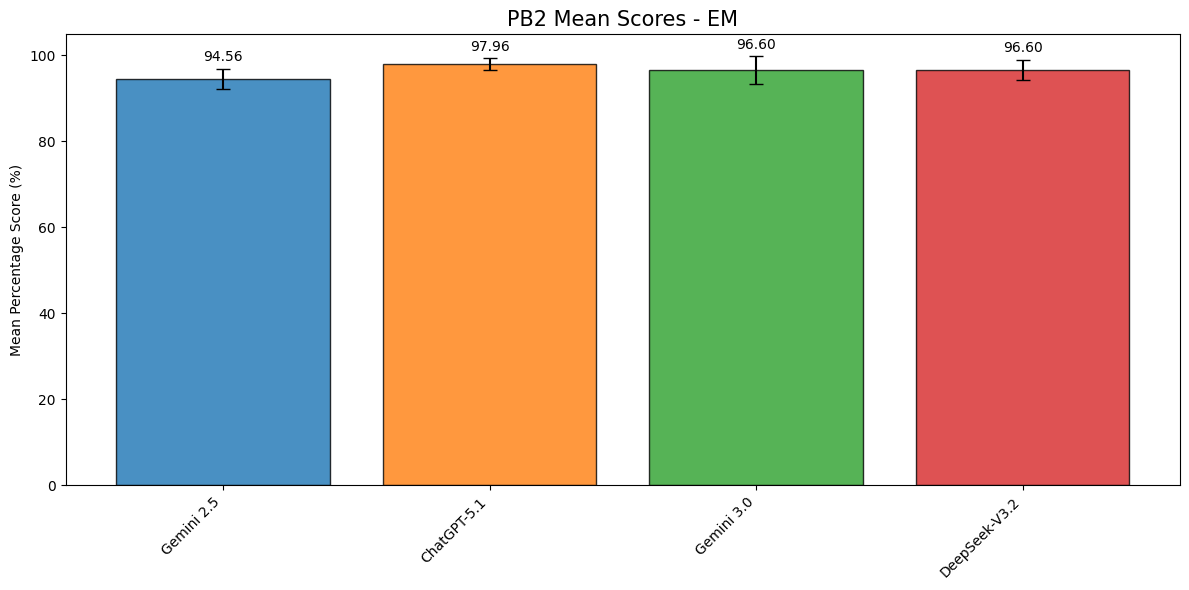

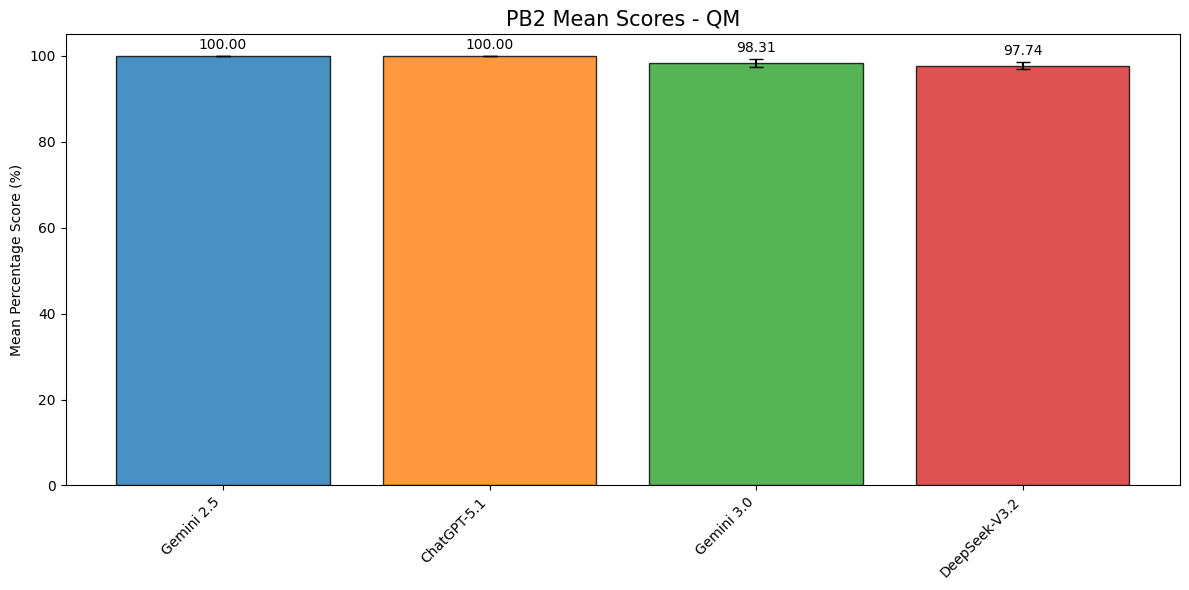

In [5]:
# Get relevant models
unique_models = master_df['Model'].unique()
model_list = [model for model in global_model_list if model in unique_models]
topic_sheet_df = summary_stats.groupby(['Dir','Sheet'])

display(topic_sheet_df.get_group(('P1', 'CM')))

# Get unique dirs and sheets for plotting
dir_list = master_df['Dir'].unique()
sheet_list = master_df['Sheet'].unique()

print("Dirs:", dir_list)
print("Sheets:", sheet_list)

# Colors
colors = ["#1b75b5", '#ff7f0e', '#2ca02c', '#d62728', "#7b46ad", '#8c564b']

safe_colors = (colors * 3) 

for dir in dir_list:
    for sheet in sheet_list:
        # Extract data
        try:
            group = topic_sheet_df.get_group((dir, sheet))
        except KeyError:
            continue # Skip completely if this Dir/Sheet combo doesn't exist
            
        group = group.dropna(subset=['Total_Mean%'])
        
        # If dropping the missing models leaves the group completely empty, skip plotting
        if group.empty:
            continue

        # 1. Grab the exact models and stats present in THIS specific group
        current_models = group['Model']
        means = group['Total_Mean%']
        std_errs = group['Total_Std_error%']

        fig, ax = plt.subplots(figsize=(12, 6))

        # 2. Set X to match the actual number of rows left in the group
        x = np.arange(len(current_models)) 
        
        # 3. Slice the colors to match the exact number of bars
        current_colors = safe_colors[:len(x)]
        
        # Plotting
        rects1 = ax.bar(x, means, width=0.8, yerr=std_errs, 
                        capsize=5, color=current_colors, edgecolor='black', alpha=0.8)

        ax.set_ylabel('Mean Percentage Score (%)')
        ax.set_title(f'PB2 Mean Scores - {sheet}',fontsize=15)
        ax.set_xticks(x)
        
        # 4. Use the current_models for the labels so they align perfectly
        ax.set_xticklabels(current_models, rotation=45, ha='right')

        # Add labels 
        ax.bar_label(rects1, padding=3, fmt='%.2f')

        # Save figure
        output_dir = '../Plots/Bar_Charts'
        os.makedirs(output_dir, exist_ok=True)
        plt.savefig(os.path.join(output_dir, f'PB_{sheet}_Bar_Chart.png'), dpi=300, bbox_inches='tight')
    

        plt.tight_layout()
        plt.show()

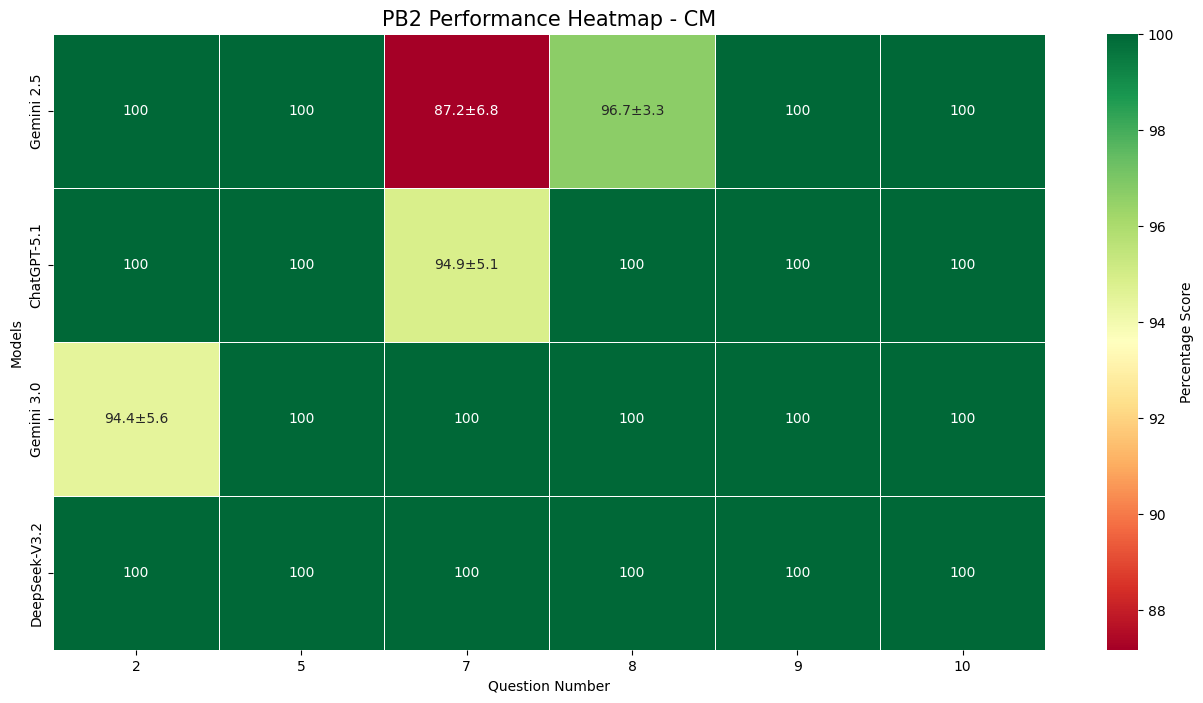

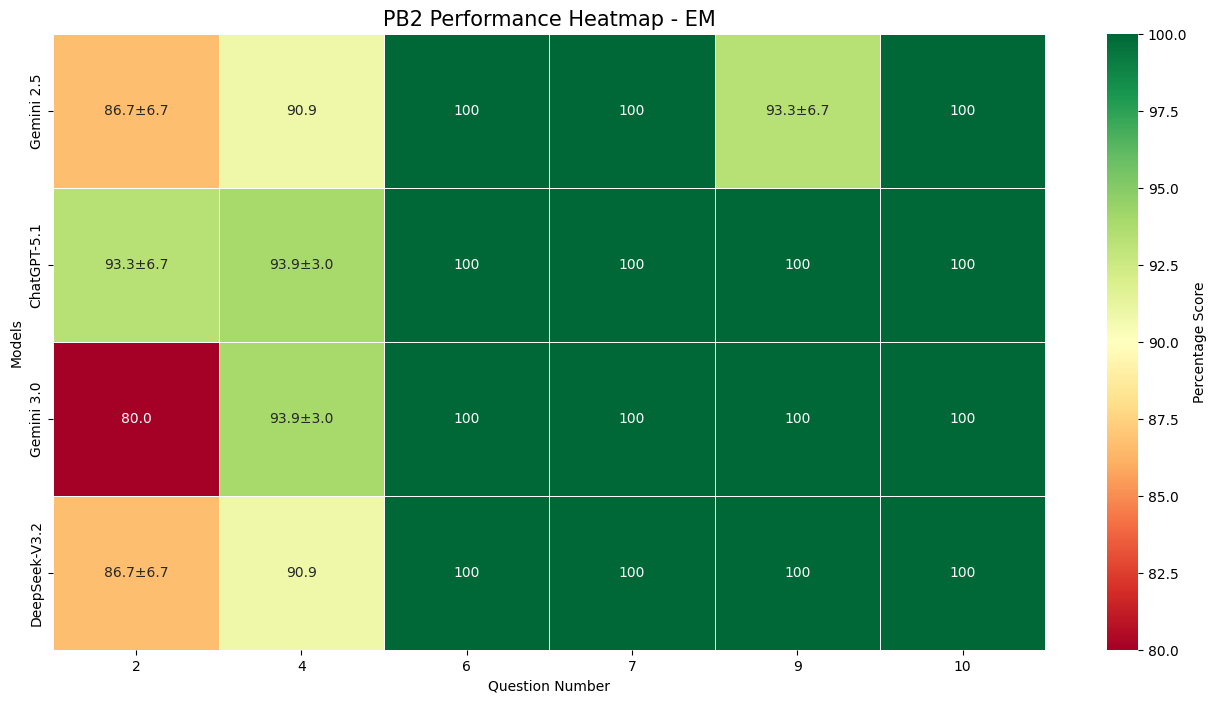

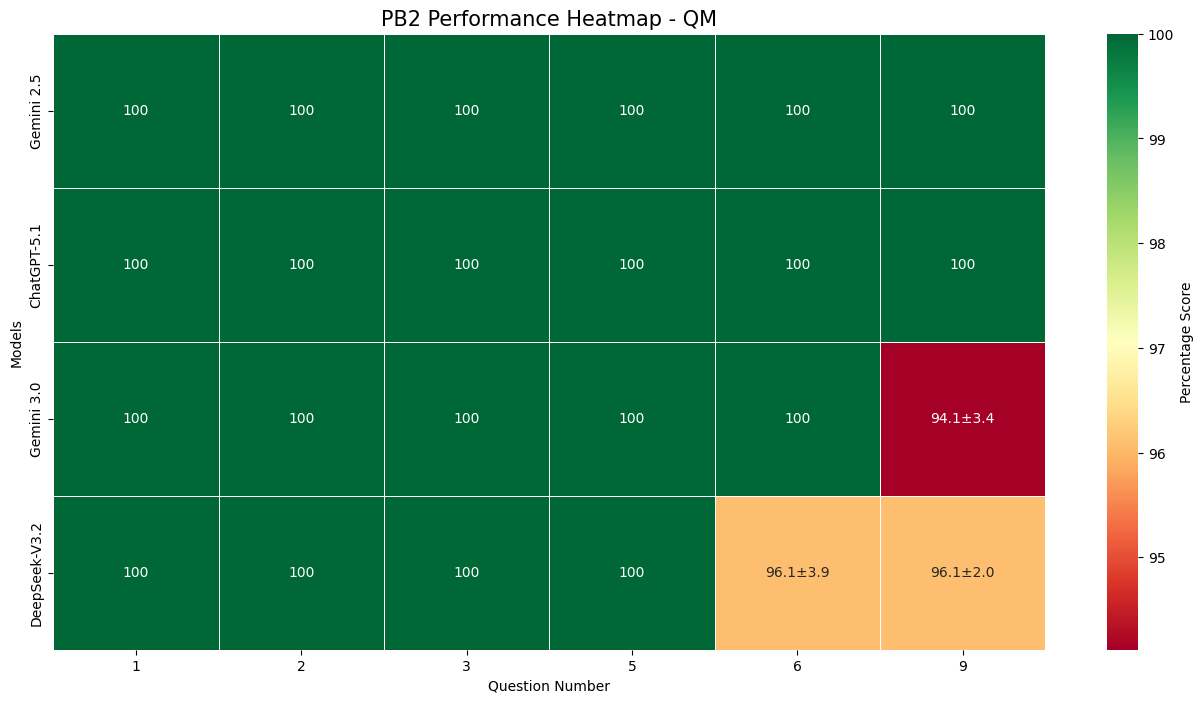

In [6]:
# 1. Define the map (Current Index: Actual Question Number)
q_map = {
    'CM': {1: 2, 2: 5, 3: 7, 4: 8, 5: 9, 6: 10},
    'QM': {1: 1, 2: 2, 3: 3, 4: 5, 5: 6, 6: 9},
    'EM': {1: 2, 2: 4, 3: 6, 4: 7, 5: 9, 6: 10}
}

master_df['Model'] = pd.Categorical(master_df['Model'], categories=model_list, ordered=True)
master_df = master_df.sort_values(['Dir', 'Model', 'Sheet', 'Question Number'])

topic_sheet_df = master_df.groupby(['Dir','Sheet'])

for dir in dir_list:
    for sheet in sheet_list:
        # Get the group
        try:
            target_group = topic_sheet_df.get_group((dir, sheet)).copy()
        except KeyError:
            continue # Skip if the dir/sheet combination doesn't exist

        # 1. Rename question numbers for each sheet
        if sheet in q_map:
            target_group['Question Number'] = target_group['Question Number'].map(q_map[sheet])
        else:
            print(f"Warning: 'Question Number' column not found in sheet: {sheet}")

        # 2. Get heatmap matrices for Mean and SE
        heatmap_matrix = target_group.pivot(index='Model', columns='Question Number', values='mean percentage mark')
        # Pivoting the standard deviation to calculate SE
        heatmap_matrix_std = target_group.pivot(index='Model', columns='Question Number', values='std percentage') 
        # Assuming n=3 based on your original logic
        heatmap_matrix_se = heatmap_matrix_std / np.sqrt(3) 

        # 3. Create the custom annotation labels
        annot_labels = np.empty(heatmap_matrix.shape, dtype=object)
        
        for i in range(heatmap_matrix.shape[0]):
            for j in range(heatmap_matrix.shape[1]):
                mean = heatmap_matrix.values[i, j]
                se = heatmap_matrix_se.values[i, j]
                
                # Handling NaN values if some model/question combos are missing
                if pd.isna(mean):
                    annot_labels[i, j] = ""
                    continue

                # If standard error is effectively 0
                if round(se, 1) == 0.0:
                    # Drop decimals for 100 and 0, otherwise 1 decimal place
                    if mean == 100.0 or mean == 0.0:
                        annot_labels[i, j] = f"{mean:.0f}" 
                    else:
                        annot_labels[i, j] = f"{mean:.1f}"
                else:
                    # Format as Mean ± SE
                    annot_labels[i, j] = f"{mean:.1f}±{se:.1f}"

        # 4. Plotting
        plt.figure(figsize=(16, 8))
        sns.heatmap(heatmap_matrix, 
                    annot=annot_labels,    
                    fmt="", # Required when passing a string matrix to annot                
                    cmap='RdYlGn',         
                    linewidths=0.5,        
                    cbar_kws={'label': 'Percentage Score'})

        plt.title(f'PB2 Performance Heatmap - {sheet}', fontsize=15)
        plt.ylabel('Models')
        plt.xlabel('Question Number')

        # Save figure
        output_dir = '../Plots/Heat_Maps'
        os.makedirs(output_dir, exist_ok=True)
        plt.savefig(os.path.join(output_dir, f'PB_{sheet}_Heat_Map.png'), dpi=300, bbox_inches='tight')

        plt.show()